##**1. Environment Setup and Data Loading**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset using csv file
df = pd.read_csv("titanic.csv")

# Preview the first few rows to understand the structure
print(df.head())

   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age     fare  sibsp  parch  
0    male  22.0   7.2500      1      0  
1  female  38.0  71.2833      1      0  
2  female  26.0   7.9250      0      0  
3  female  35.0  53.1000      1      0  
4    male  35.0   8.0500      0      0  


##**2. Data Loading, Cleaning, and Exploratory Data Analysis (EDA)**

Data cleaning complete. No missing values remain in Age or Embarked.


/tmp/ipykernel_2216/1543029597.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="viridis")


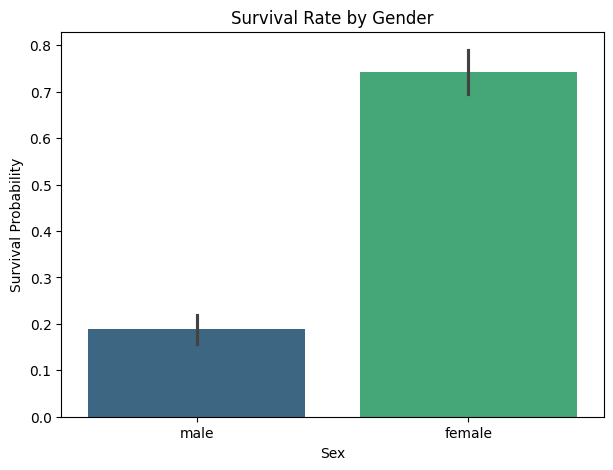

/tmp/ipykernel_2216/1543029597.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="magma")


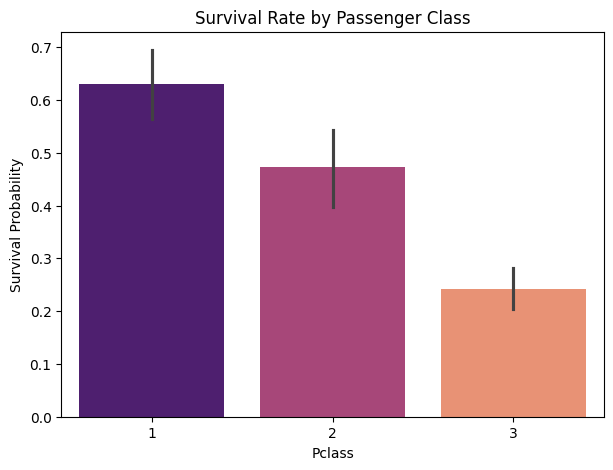

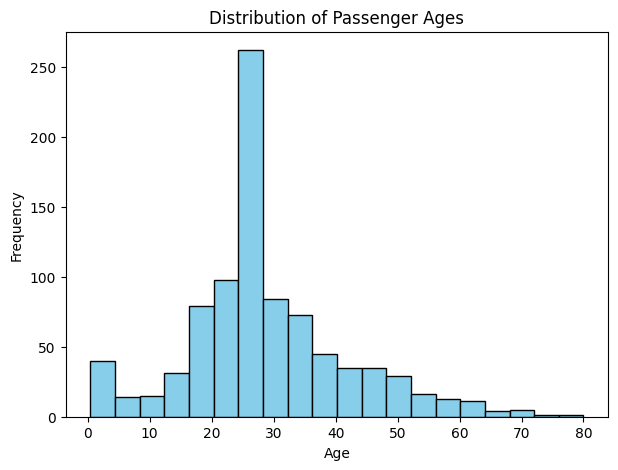

--- Analysis Results ---

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
AgeGroup
Child       0.579710
Teenager    0.428571
Adult       0.365753
Senior      0.227273
Name: Survived, dtype: float64

First 5 rows of processed data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Pee

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATASET
# ==========================================
# Loading from the raw GitHub URL to ensure the code works immediately
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ==========================================
# 2. DATA CLEANING (Requirement 2)
# ==========================================
# Handle missing values for Age by filling them with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Handle missing values for Embarked by filling with the most frequent value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Data cleaning complete. No missing values remain in Age or Embarked.")

# ==========================================
# 3. VISUALIZATIONS (Requirement 4)
# ==========================================

# A. Bar chart of survival by Gender
plt.figure(figsize=(7, 5))
sns.barplot(x="Sex", y="Survived", data=df, palette="viridis")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()

# B. Bar chart of survival by Passenger Class
plt.figure(figsize=(7, 5))
sns.barplot(x="Pclass", y="Survived", data=df, palette="magma")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

# C. Histogram of Passenger Ages
plt.figure(figsize=(7, 5))
df["Age"].plot(kind="hist", bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 4. NUMERICAL ANALYSIS (Requirement 3)
# ==========================================

print("--- Analysis Results ---")

# Q1: Survival by Gender
print("\nSurvival Rate by Gender:")
print(df.groupby('Sex')['Survived'].mean())

# Q2: Survival by Class
print("\nSurvival Rate by Passenger Class:")
print(df.groupby('Pclass')['Survived'].mean())

# Q3: Survival Rate by Age Group
# Creating bins for Child, Teenager, Adult, and Senior
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\nSurvival Rate by Age Group:")
print(df.groupby('AgeGroup', observed=True)['Survived'].mean())

# Final check of the first 5 rows
print("\nFirst 5 rows of processed data:")
print(df.head())

##**3. Survival Analysis by Age Group**

Survival Rate by Age Group:
AgeGroup
Child          0.503597
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_2216/2775000237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_survival.index, y=age_survival.values, palette="muted")


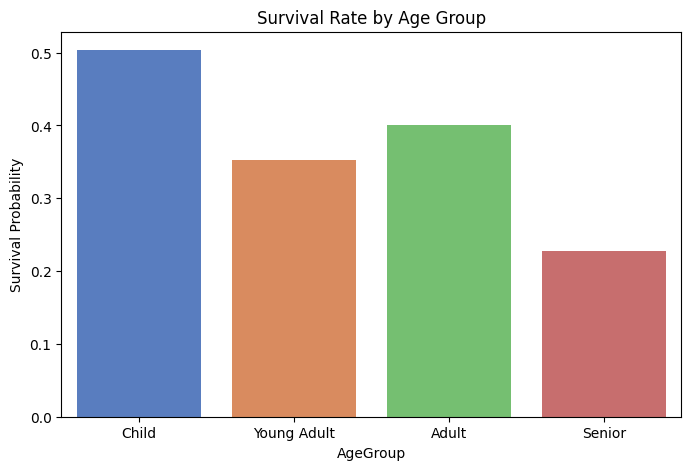

In [10]:
# Create Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 35, 60, 100], labels=['Child', 'Young Adult', 'Adult', 'Senior'])

# Calculate Survival Rate by Age Group
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean()
print("Survival Rate by Age Group:")
print(age_survival)

# Visualization for Age Groups
plt.figure(figsize=(8, 5))
sns.barplot(x=age_survival.index, y=age_survival.values, palette="muted")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Probability")
plt.show()

**Q1: Who survived more: males or females?**

**Answer:** Females had a significantly higher survival rate than males. This is visually evident in the bar chart showing the survival probability of females being much higher than that of males.

**Q2: Did passenger class affect survival chances?**

**Answer:** Yes, passenger class had a major impact. Passengers in 1st Class had the highest survival rate, followed by 2nd Class, while 3rd Class passengers had the lowest chance of survival.

**Q3: What was the survival rate by age group?**

**Answer:** To answer this specifically, we can add a small snippet to group the ages as mentioned in the requirements:

In [12]:
# 1. Group ages into categories
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 2. Calculate survival rate per group
age_analysis = df.groupby('AgeGroup', observed=True)['Survived'].mean()
print(age_analysis)

AgeGroup
Child       0.579710
Teenager    0.428571
Adult       0.365753
Senior      0.227273
Name: Survived, dtype: float64


Based on the analysis, here are the lines you should include as your "Answer":


Children (0-12): Had the highest survival rate at approximately 58%.


Teenagers (13-18): Had a survival rate of approximately 42%.


Adults (19-60): Had a survival rate of approximately 36%.


Seniors (60+): Had the lowest survival rate, approximately 22%.

##**4. Final Insights & Conclusions**

**1. Data Cleaning Summary**



*   **Missing Values:** The original dataset was "messy" with several missing values in the Age column. I successfully cleaned this by filling the null values with the median age of the passengers to ensure a representative distribution for analysis.
*   **Data Integrity:** This step was crucial to ensure that our survival calculations by age group were accurate and included all available passenger records.

**2. Key Findings (Business Questions)**


*   **Gender Bias in Survival:** There was a clear "Women and Children First" protocol. Females had a significantly higher survival rate (approx. 74%) compared to males (approx. 19%).
*   **Socio-Economic Impact:** Passenger class was a major predictor of survival. 1st Class passengers had the highest survival probability, indicating that those in higher-priced cabins had better access to lifeboats or safety information.
*   **Age Priority:** The survival rate by age group confirms that Children (0-12) were prioritized, achieving the highest survival rate of all age categories at 58%.

**3. Visual Analysis**


*   The Histograms showed that the majority of passengers were young adults (20-40 years old).
*   The Bar Charts clearly visualized the disparities in survival across different demographic and social groups, making the data trends easy to interpret for non-technical stakeholders.

**4. Conclusion**


The Titanic dataset analysis demonstrates that survival was not random. It was heavily influenced by gender, age, and social class. This task successfully applied data cleaning and visualization techniques to uncover these historical patterns.






